# SEAS 8515 – Data Engineering for AI
## Homework 4 (Summer 2026)

## Question 1: Getting Started with Databricks
This question **must** be completed using Databricks.

Embed screenshots directly in this notebook using either Markdown or load the image and display using another Python library (such as opencv or PIL).

### Screenshot: Databricks Workspace

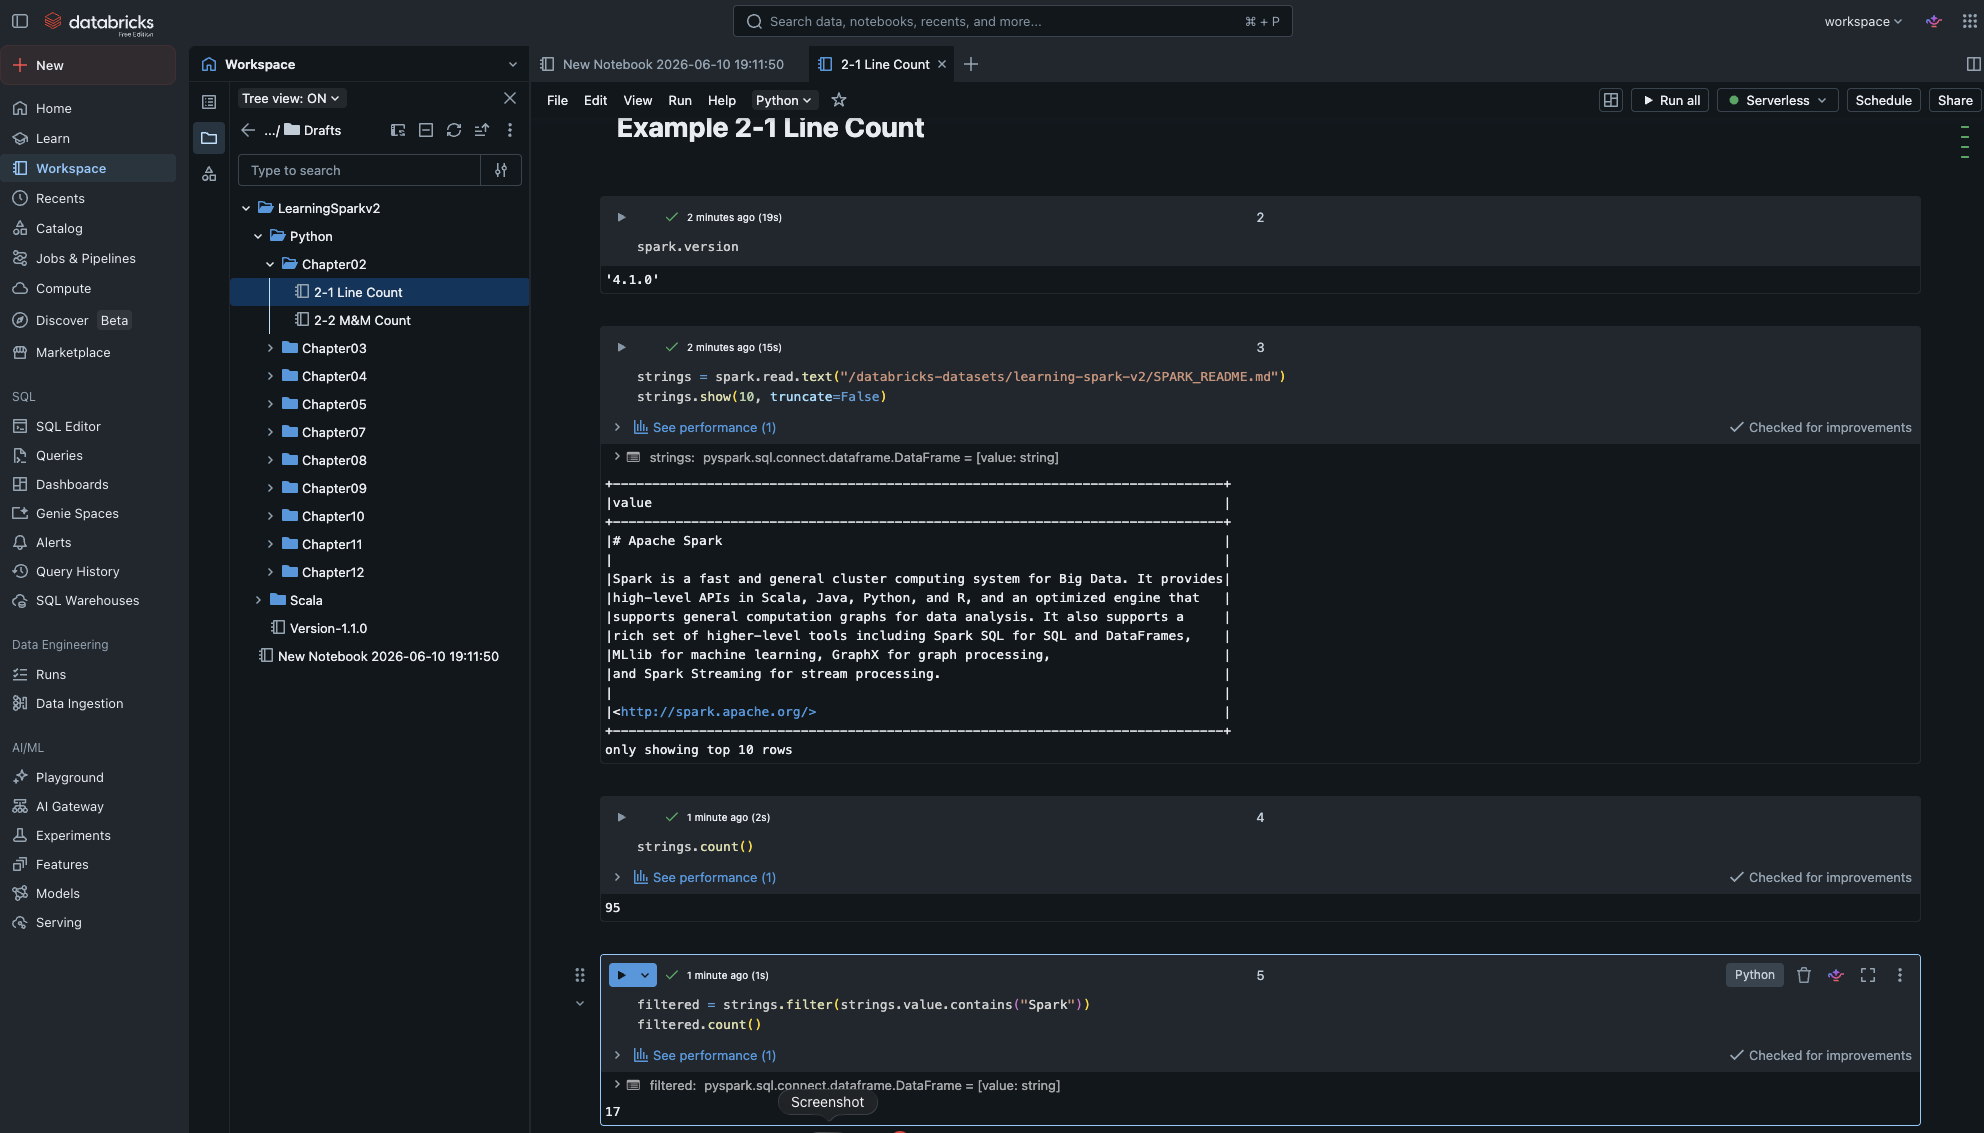

### Screenshot: Uploaded learning_sparkv2.dbc Folder

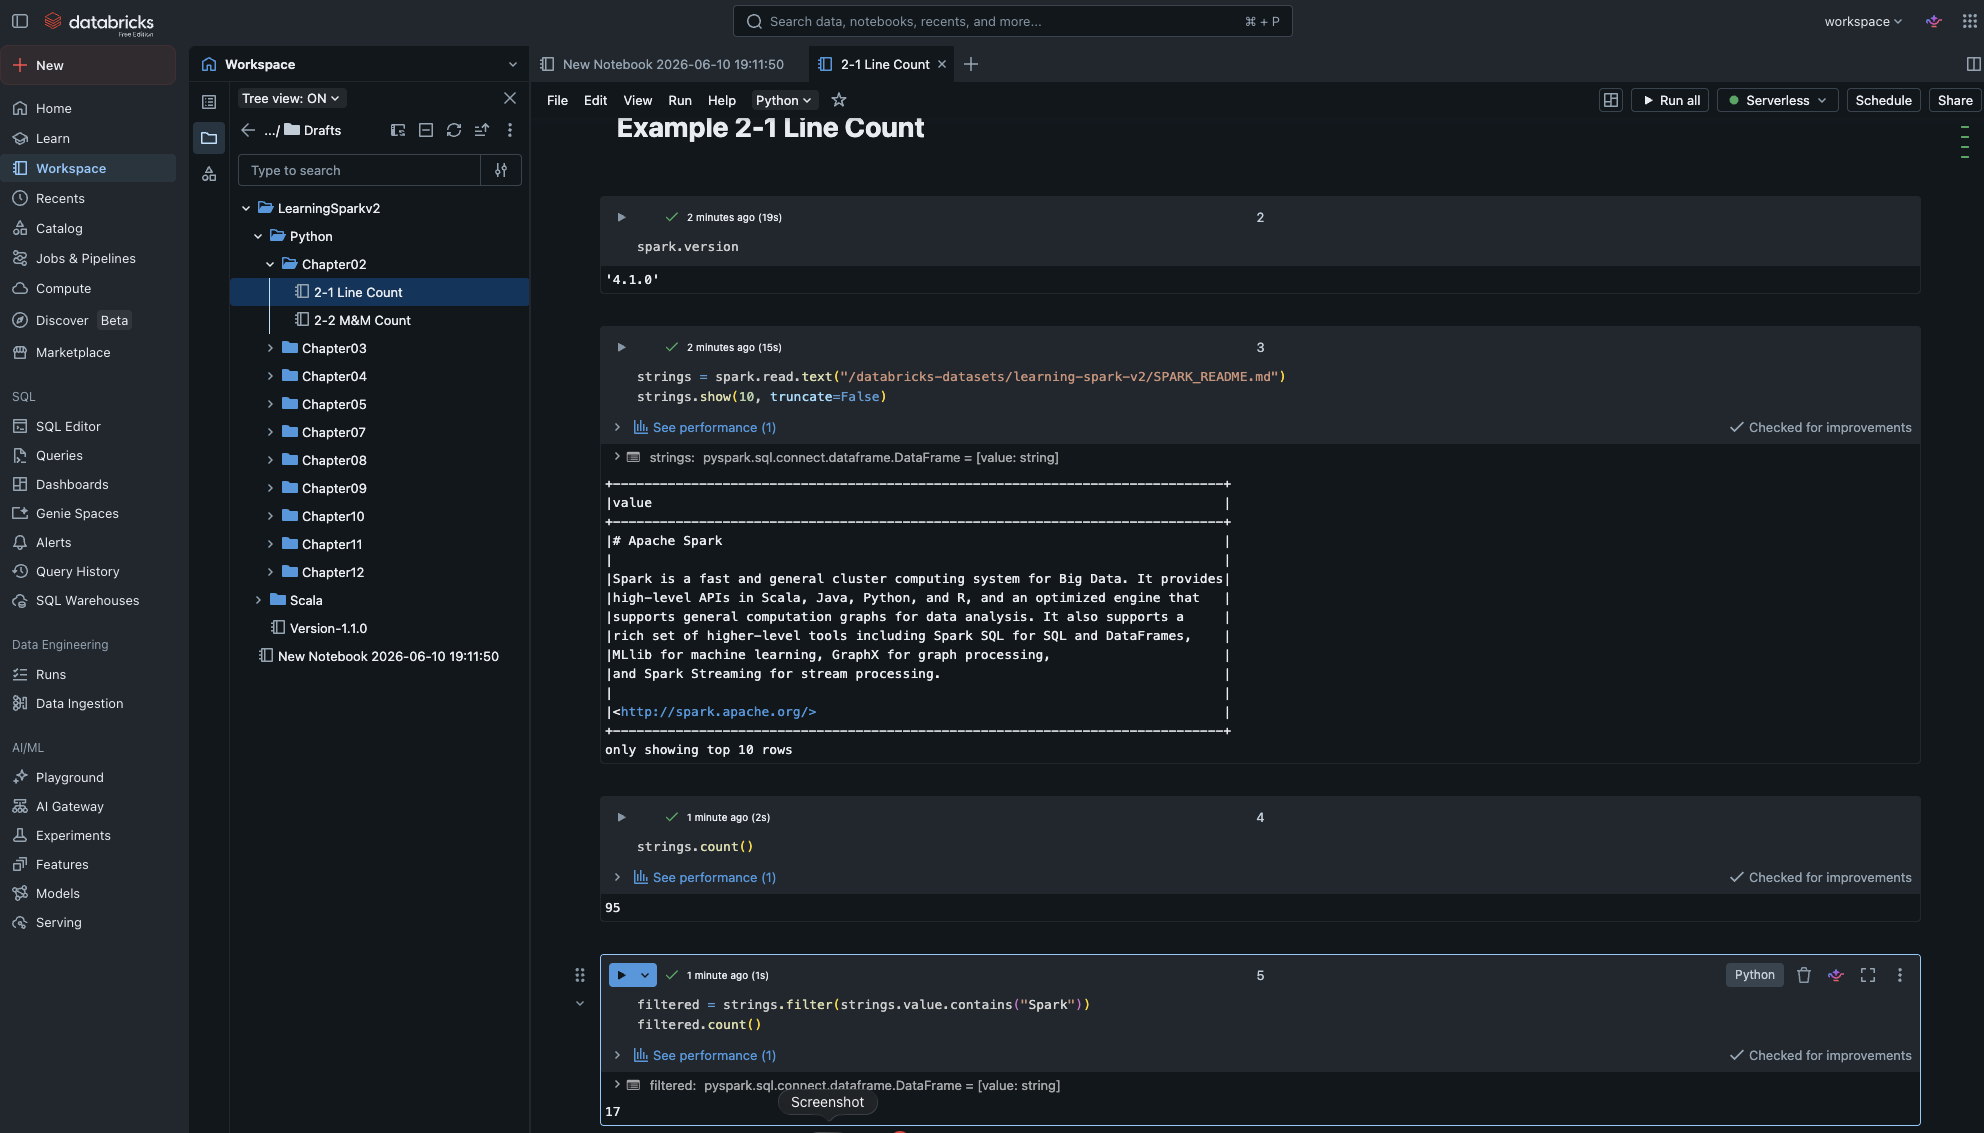

### Screenshot: Executed Notebook

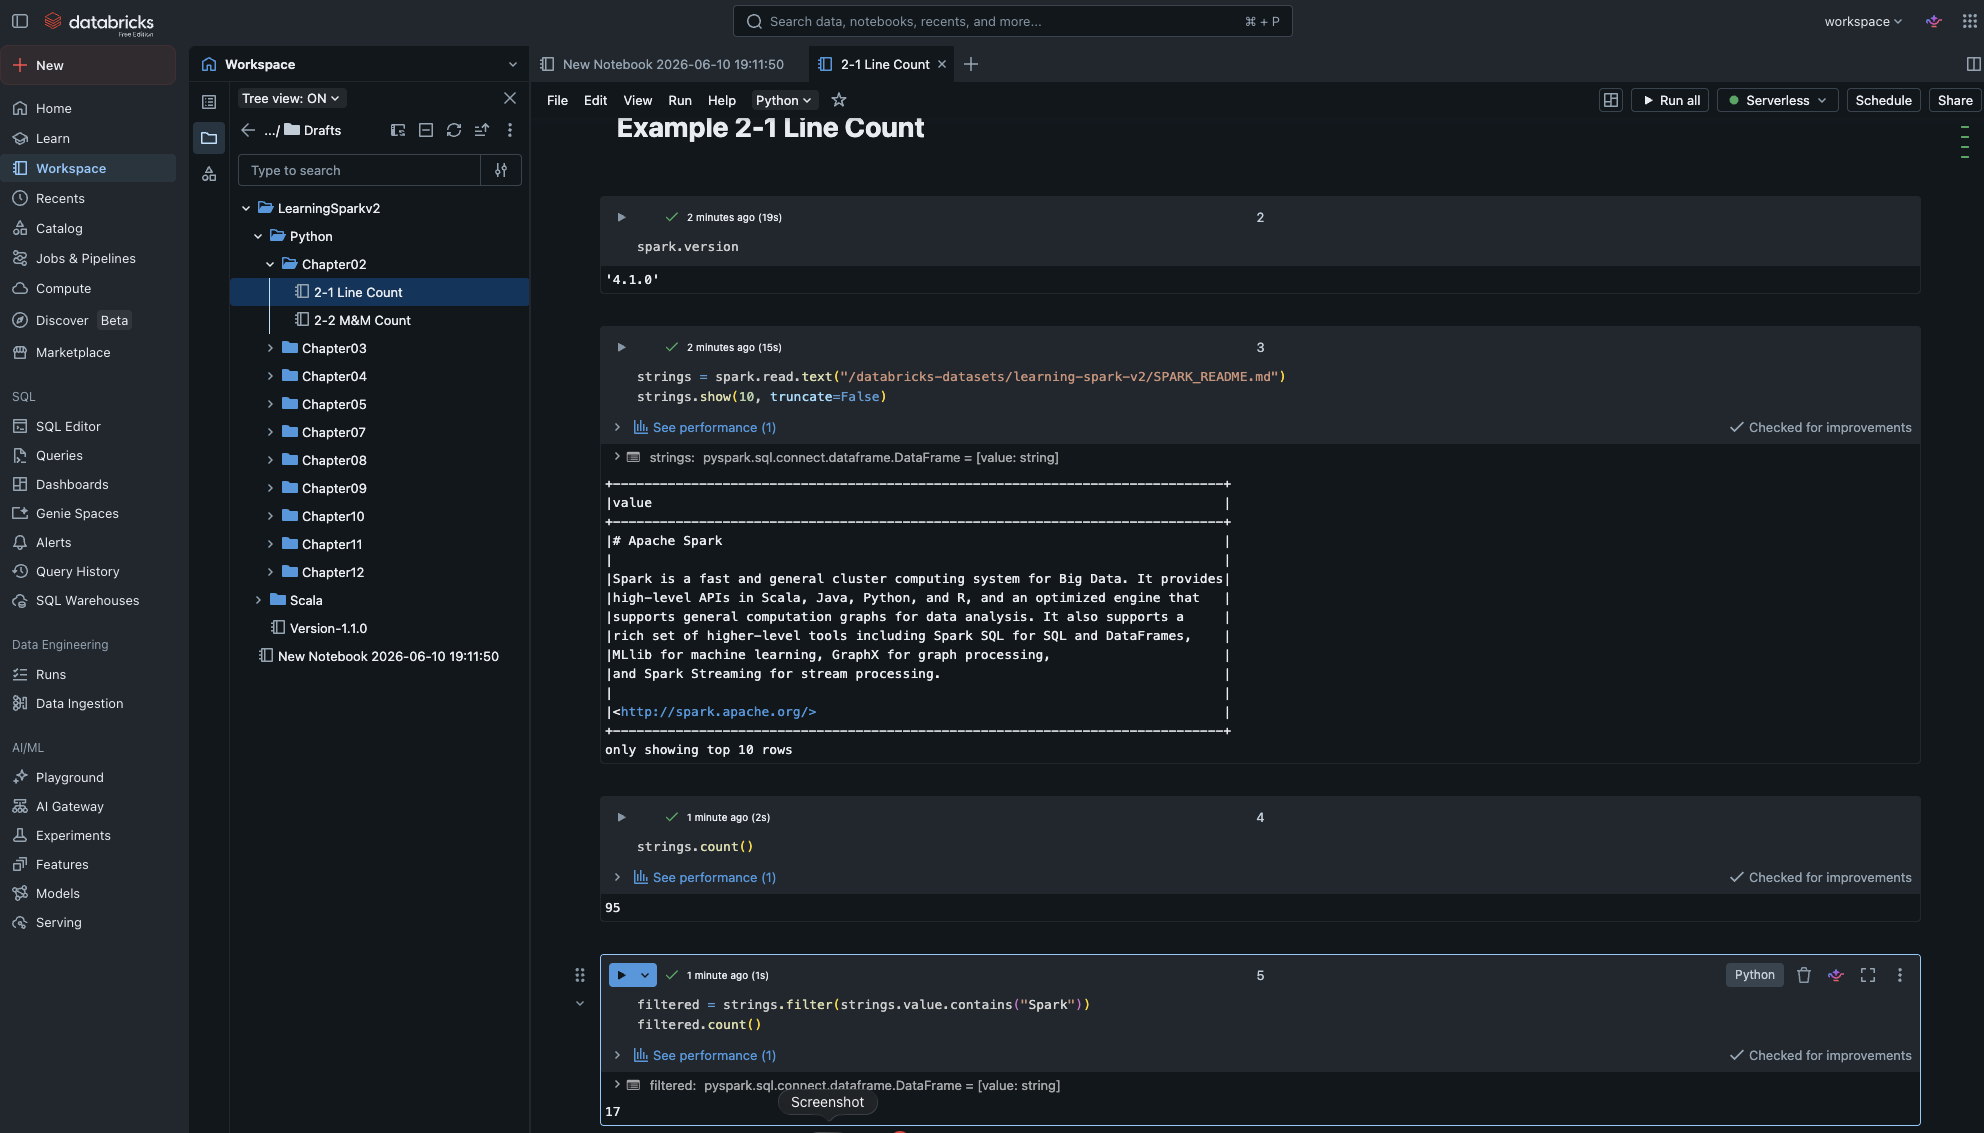

## Question 2: Analyze Text Data with Spark
Use PySpark. Databricks or Google Colab is acceptable.
You must use the provided `assignment_4.txt` file.

In [1]:
import os, sys
from pathlib import Path
if not os.environ.get("JAVA_HOME"):
    for _c in ["/opt/homebrew/opt/openjdk@17", "/opt/homebrew/opt/openjdk"]:
        if Path(_c).exists():
            os.environ["JAVA_HOME"] = _c
            os.environ["PATH"] = f"{_c}/bin:{os.environ['PATH']}"
            break
os.environ["PYSPARK_PYTHON"] = os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
if "spark" not in globals():
    from pyspark.sql import SparkSession
    spark = SparkSession.builder.master("local[*]").appName("SEAS8515_HW4").getOrCreate()
    spark.sparkContext.setLogLevel("ERROR")
_nb = globals().get("__vsc_ipynb_file__", "")
DATA_DIR = Path(_nb).parent.parent / "data" if _nb else Path("/Users/kimshellenberger/GIT/shellenberger-drschool/data")

print("SparkSession ready")
print(f"Data directory: {DATA_DIR}")
spark

SparkSession ready
Data directory: /Users/kimshellenberger/GIT/shellenberger-drschool/data


In [2]:
import os, sys
from pathlib import Path
if not os.environ.get("JAVA_HOME"):
    for _c in ["/opt/homebrew/opt/openjdk@17", "/opt/homebrew/opt/openjdk"]:
        if Path(_c).exists():
            os.environ["JAVA_HOME"] = _c
            os.environ["PATH"] = f"{_c}/bin:{os.environ['PATH']}"
            break
os.environ["PYSPARK_PYTHON"] = os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
if "spark" not in globals():
    from pyspark.sql import SparkSession
    spark = SparkSession.builder.master("local[*]").appName("SEAS8515_HW4").getOrCreate()
    spark.sparkContext.setLogLevel("ERROR")
_nb = globals().get("__vsc_ipynb_file__", "")
DATA_DIR = Path(_nb).parent.parent / "data" if _nb else Path("/Users/kimshellenberger/GIT/shellenberger-drschool/data")

TEXT_FILE = str(DATA_DIR / "assignment_4.txt")
text_rdd = spark.sparkContext.textFile(TEXT_FILE)

print("First 10 lines:")
for line in text_rdd.take(10):
    print(line)

First 10 lines:
TensorFlow is an open-source machine learning and deep learning framework originally developed by Google.
It is designed to support the development, training, and deployment of machine learning models at scale.
TensorFlow is widely used in research, industry, and education due to its flexibility and performance.
At the core of TensorFlow is the concept of a tensor. A tensor is a multi-dimensional array used to represent
data. Scalars are zero-dimensional tensors, vectors are one-dimensional tensors, and matrices are
two-dimensional tensors. Higher-order tensors are used to represent more complex data such as images,
videos, and batches of training examples.
TensorFlow operates using a dataflow programming model. Computations are expressed as graphs where nodes


In [3]:
import os, sys
from pathlib import Path
if not os.environ.get("JAVA_HOME"):
    for _c in ["/opt/homebrew/opt/openjdk@17", "/opt/homebrew/opt/openjdk"]:
        if Path(_c).exists():
            os.environ["JAVA_HOME"] = _c
            os.environ["PATH"] = f"{_c}/bin:{os.environ['PATH']}"
            break
os.environ["PYSPARK_PYTHON"] = os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
if "spark" not in globals():
    from pyspark.sql import SparkSession
    spark = SparkSession.builder.master("local[*]").appName("SEAS8515_HW4").getOrCreate()
    spark.sparkContext.setLogLevel("ERROR")
_nb = globals().get("__vsc_ipynb_file__", "")
DATA_DIR = Path(_nb).parent.parent / "data" if _nb else Path("/Users/kimshellenberger/GIT/shellenberger-drschool/data")
if "text_rdd" not in globals():
    text_rdd = spark.sparkContext.textFile(str(DATA_DIR / "assignment_4.txt"))

total_lines = text_rdd.count()
print(f"Total number of lines: {total_lines}")

Total number of lines: 36


In [4]:
import os, sys
from pathlib import Path
if not os.environ.get("JAVA_HOME"):
    for _c in ["/opt/homebrew/opt/openjdk@17", "/opt/homebrew/opt/openjdk"]:
        if Path(_c).exists():
            os.environ["JAVA_HOME"] = _c
            os.environ["PATH"] = f"{_c}/bin:{os.environ['PATH']}"
            break
os.environ["PYSPARK_PYTHON"] = os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
if "spark" not in globals():
    from pyspark.sql import SparkSession
    spark = SparkSession.builder.master("local[*]").appName("SEAS8515_HW4").getOrCreate()
    spark.sparkContext.setLogLevel("ERROR")
_nb = globals().get("__vsc_ipynb_file__", "")
DATA_DIR = Path(_nb).parent.parent / "data" if _nb else Path("/Users/kimshellenberger/GIT/shellenberger-drschool/data")
if "text_rdd" not in globals():
    text_rdd = spark.sparkContext.textFile(str(DATA_DIR / "assignment_4.txt"))

tensor_lines = text_rdd.filter(lambda line: "tensor" in line.lower())
tensor_count = tensor_lines.count()
print(f"Number of lines containing 'tensor': {tensor_count}")

print("\nMatching lines:")
for line in tensor_lines.collect():
    print(line)

Number of lines containing 'tensor': 23
Matching lines:
TensorFlow is an open-source machine learning and deep learning framework originally developed by Google.
TensorFlow is widely used in research, industry, and education due to its flexibility and performance.
At the core of TensorFlow is the concept of a tensor. A tensor is a multi-dimensional array used to represent
data. Scalars are zero-dimensional tensors, vectors are one-dimensional tensors, and matrices are
two-dimensional tensors. Higher-order tensors are used to represent more complex data such as images,
TensorFlow operates using a dataflow programming model. Computations are expressed as graphs where nodes
represent operations and edges represent tensors flowing between those operations. This structure allows
TensorFlow to optimize how tensors move through memory and across hardware devices.
One of TensorFlow's key advantages is its ability to execute tensor operations on different types of hardware.
TensorFlow supports 

## Question 3: Aggregation and Filtering with Spark
Use PySpark DataFrame operations.

In [5]:
import os, sys
from pathlib import Path
if not os.environ.get("JAVA_HOME"):
    for _c in ["/opt/homebrew/opt/openjdk@17", "/opt/homebrew/opt/openjdk"]:
        if Path(_c).exists():
            os.environ["JAVA_HOME"] = _c
            os.environ["PATH"] = f"{_c}/bin:{os.environ['PATH']}"
            break
os.environ["PYSPARK_PYTHON"] = os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
if "spark" not in globals():
    from pyspark.sql import SparkSession
    spark = SparkSession.builder.master("local[*]").appName("SEAS8515_HW4").getOrCreate()
    spark.sparkContext.setLogLevel("ERROR")
_nb = globals().get("__vsc_ipynb_file__", "")
DATA_DIR = Path(_nb).parent.parent / "data" if _nb else Path("/Users/kimshellenberger/GIT/shellenberger-drschool/data")

from pyspark.sql.functions import count, desc, col

CANCER_FILE = str(DATA_DIR / "cancer_dataset_uae(1).csv")
df = spark.read.csv(CANCER_FILE, header=True, inferSchema=True)
print(f"Rows: {df.count()}  Columns: {len(df.columns)}")
df.printSchema()
df.show(5)

Rows: 10000  Columns: 20
root
 |-- Patient_ID: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Nationality: string (nullable = true)
 |-- Emirate: string (nullable = true)
 |-- Diagnosis_Date: date (nullable = true)
 |-- Cancer_Type: string (nullable = true)
 |-- Cancer_Stage: string (nullable = true)
 |-- Treatment_Type: string (nullable = true)
 |-- Treatment_Start_Date: date (nullable = true)
 |-- Hospital: string (nullable = true)
 |-- Primary_Physician: string (nullable = true)
 |-- Outcome: string (nullable = true)
 |-- Death_Date: string (nullable = true)
 |-- Cause_of_Death: string (nullable = true)
 |-- Smoking_Status: string (nullable = true)
 |-- Comorbidities: string (nullable = true)
 |-- Ethnicity: string (nullable = true)
 |-- Weight: integer (nullable = true)
 |-- Height: integer (nullable = true)
+----------+---+------+-----------+-------------+--------------+-----------+------------+--------------+---------------

In [6]:
import os, sys
from pathlib import Path
if not os.environ.get("JAVA_HOME"):
    for _c in ["/opt/homebrew/opt/openjdk@17", "/opt/homebrew/opt/openjdk"]:
        if Path(_c).exists():
            os.environ["JAVA_HOME"] = _c
            os.environ["PATH"] = f"{_c}/bin:{os.environ['PATH']}"
            break
os.environ["PYSPARK_PYTHON"] = os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
if "spark" not in globals():
    from pyspark.sql import SparkSession
    spark = SparkSession.builder.master("local[*]").appName("SEAS8515_HW4").getOrCreate()
    spark.sparkContext.setLogLevel("ERROR")
_nb = globals().get("__vsc_ipynb_file__", "")
DATA_DIR = Path(_nb).parent.parent / "data" if _nb else Path("/Users/kimshellenberger/GIT/shellenberger-drschool/data")
if "df" not in globals():
    from pyspark.sql.functions import count, desc, col
    df = spark.read.csv(str(DATA_DIR / "cancer_dataset_uae(1).csv"), header=True, inferSchema=True)

cancer_outcome = (
    df.groupBy("Cancer_Type", "Outcome")
    .agg(count("*").alias("total_patients"))
    .orderBy(desc("total_patients"))
)
print("Patient counts by Cancer Type and Outcome (descending):")
cancer_outcome.show(truncate=False)

Patient counts by Cancer Type and Outcome (descending):
+-----------+---------------+--------------+
|Cancer_Type|Outcome        |total_patients|
+-----------+---------------+--------------+
|Leukemia   |Recovered      |660           |
|Liver      |Recovered      |630           |
|Colorectal |Recovered      |618           |
|Lung       |Recovered      |615           |
|Breast     |Recovered      |614           |
|Ovarian    |Recovered      |601           |
|Prostate   |Recovered      |599           |
|Pancreatic |Recovered      |594           |
|Ovarian    |Under Treatment|530           |
|Leukemia   |Under Treatment|527           |
|Liver      |Under Treatment|518           |
|Breast     |Under Treatment|507           |
|Prostate   |Under Treatment|506           |
|Pancreatic |Under Treatment|504           |
|Colorectal |Under Treatment|499           |
|Lung       |Under Treatment|486           |
|Pancreatic |Deceased       |145           |
|Lung       |Deceased       |132           |

In [7]:
import os, sys
from pathlib import Path
if not os.environ.get("JAVA_HOME"):
    for _c in ["/opt/homebrew/opt/openjdk@17", "/opt/homebrew/opt/openjdk"]:
        if Path(_c).exists():
            os.environ["JAVA_HOME"] = _c
            os.environ["PATH"] = f"{_c}/bin:{os.environ['PATH']}"
            break
os.environ["PYSPARK_PYTHON"] = os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
if "spark" not in globals():
    from pyspark.sql import SparkSession
    spark = SparkSession.builder.master("local[*]").appName("SEAS8515_HW4").getOrCreate()
    spark.sparkContext.setLogLevel("ERROR")
_nb = globals().get("__vsc_ipynb_file__", "")
DATA_DIR = Path(_nb).parent.parent / "data" if _nb else Path("/Users/kimshellenberger/GIT/shellenberger-drschool/data")
if "df" not in globals():
    from pyspark.sql.functions import count, desc, col
    df = spark.read.csv(str(DATA_DIR / "cancer_dataset_uae(1).csv"), header=True, inferSchema=True)

abu_dhabi_treatments = (
    df.filter(col("Emirate") == "Abu Dhabi")
    .groupBy("Treatment_Type")
    .agg(count("*").alias("patient_count"))
    .orderBy(desc("patient_count"))
    .limit(5)
)
print("Top 5 treatment types for Abu Dhabi patients:")
abu_dhabi_treatments.show(truncate=False)

Top 5 treatment types for Abu Dhabi patients:
+--------------+-------------+
|Treatment_Type|patient_count|
+--------------+-------------+
|Surgery       |379          |
|Radiation     |373          |
|Chemotherapy  |364          |
|Immunotherapy |355          |
+--------------+-------------+


In [8]:
import os, sys
from pathlib import Path
if not os.environ.get("JAVA_HOME"):
    for _c in ["/opt/homebrew/opt/openjdk@17", "/opt/homebrew/opt/openjdk"]:
        if Path(_c).exists():
            os.environ["JAVA_HOME"] = _c
            os.environ["PATH"] = f"{_c}/bin:{os.environ['PATH']}"
            break
os.environ["PYSPARK_PYTHON"] = os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
if "spark" not in globals():
    from pyspark.sql import SparkSession
    spark = SparkSession.builder.master("local[*]").appName("SEAS8515_HW4").getOrCreate()
    spark.sparkContext.setLogLevel("ERROR")
_nb = globals().get("__vsc_ipynb_file__", "")
DATA_DIR = Path(_nb).parent.parent / "data" if _nb else Path("/Users/kimshellenberger/GIT/shellenberger-drschool/data")
if "df" not in globals():
    from pyspark.sql.functions import count, desc, col
    df = spark.read.csv(str(DATA_DIR / "cancer_dataset_uae(1).csv"), header=True, inferSchema=True)

from pyspark.sql.functions import round as spark_round

smoking_outcome = (
    df.groupBy("Smoking_Status", "Outcome")
    .agg(count("*").alias("patient_count"))
    .orderBy("Smoking_Status", "Outcome")
)
print("Patient counts by Smoking Status and Outcome:")
smoking_outcome.show(truncate=False)

total_per_group = df.groupBy("Smoking_Status").agg(count("*").alias("total"))
recovered = (
    df.filter(col("Outcome") == "Recovered")
    .groupBy("Smoking_Status")
    .agg(count("*").alias("recovered"))
)
summary = (
    total_per_group.join(recovered, "Smoking_Status", "left")
    .withColumn("recovery_rate_pct", spark_round((col("recovered") / col("total")) * 100, 1))
    .orderBy("Smoking_Status")
)
print("\nRecovery rate by Smoking Status:")
summary.show(truncate=False)

Patient counts by Smoking Status and Outcome:
+--------------+---------------+-------------+
|Smoking_Status|Outcome        |patient_count|
+--------------+---------------+-------------+
|Former Smoker |Deceased       |195          |
|Former Smoker |Recovered      |929          |
|Former Smoker |Under Treatment|793          |
|Non-Smoker    |Deceased       |492          |
|Non-Smoker    |Recovered      |2515         |
|Non-Smoker    |Under Treatment|2031         |
|Smoker        |Deceased       |305          |
|Smoker        |Recovered      |1487         |
|Smoker        |Under Treatment|1253         |
+--------------+---------------+-------------+
Recovery rate by Smoking Status:
+--------------+-----+---------+-----------------+
|Smoking_Status|total|recovered|recovery_rate_pct|
+--------------+-----+---------+-----------------+
|Former Smoker |1917 |929      |48.5             |
|Non-Smoker    |5038 |2515     |49.9             |
|Smoker        |3045 |1487     |48.8             |
+---